# BITS F464 : Machine Learning - Assignment 5
Time Series Forecasting (Energy Consumption Forecasting) using LSTMs

Adit Rastogi <br>
2022A7PS1330H <br><br>
Deeptansh Gupta <br>
2022A7PS1336H <br><br>
Anirban Nayak <br>
2022A3PS0705H <br>

## Data Pre-Processing

### Importing the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from math import sqrt

In [ ]:
data = pd.read_csv("./household_power_consumption.txt", sep=";", low_memory=False)
print(data.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


### Loading the CSV file into pandas DataFrame

In [ ]:
df = pd.DataFrame(data)
print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [ ]:
print(data.shape)

(2075259, 9)


In [ ]:
print(df.dtypes)

Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


In [ ]:
columns_to_convert = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Coerce invalid parsing into NaN

In [ ]:
print("Data types after conversion:")
print(df[columns_to_convert].dtypes)

Data types after conversion:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
dtype: object


In [ ]:
features = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']

In [ ]:
df[features] = df[features].astype(float)

In [ ]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
print(df['Datetime'].head())

0   2006-12-16 17:24:00
1   2006-12-16 17:25:00
2   2006-12-16 17:26:00
3   2006-12-16 17:27:00
4   2006-12-16 17:28:00
Name: Datetime, dtype: datetime64[ns]


In [ ]:
print(df.dtypes)

Date                             object
Time                             object
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                   object
Sub_metering_2                   object
Sub_metering_3                  float64
Datetime                 datetime64[ns]
dtype: object


In [ ]:
# Ensure 'Datetime' is the index before resampling
df.set_index('Datetime', inplace=True)

# Resample to daily frequency and compute sum for each day
daily_df = df.resample('D').sum()

# Select only the required columns
columns_to_keep = ['Global_active_power','Global_reactive_power', 'Global_intensity', 'Voltage']
daily_df = daily_df[columns_to_keep]

# Check the result
print(daily_df.head())

            Global_active_power  Global_reactive_power  Global_intensity  \
Datetime                                                                   
2006-12-16             1209.176                 34.922            5180.8   
2006-12-17             3390.460                226.006           14398.6   
2006-12-18             2203.826                161.792            9247.2   
2006-12-19             1666.194                150.942            7094.0   
2006-12-20             2225.748                160.998            9313.0   

              Voltage  
Datetime               
2006-12-16   93552.53  
2006-12-17  345725.32  
2006-12-18  347373.64  
2006-12-19  348479.01  
2006-12-20  348923.61  


### Data-Scaling

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(daily_df)

In [ ]:
print(data_scaled.shape)

(1442, 4)


## LSTM Model Development

### Creation of Sequences

In [ ]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # Target is the first column (Global_active_power)
    return np.array(X), np.array(y)

window_size = 5
X, y = create_sequences(data_scaled, window_size)

### Training and Testing

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### Model Configuration

In [ ]:
model = Sequential([
    Input(shape=(5, 4)),
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dense(1)  # Output single value (daily forecast)
])


In [ ]:
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 5, 50)               │          11,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X_train.shape)  # Should output (samples, timesteps, features)
print(y_train.shape)  # Should output (samples,)

(1149, 5, 4)
(1149,)


In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - loss: 0.0831 - val_loss: 0.0209
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0183 - val_loss: 0.0139
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0161 - val_loss: 0.0109
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0144 - val_loss: 0.0086
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0126 - val_loss: 0.0072
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0127 - val_loss: 0.0084
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0131 - val_loss: 0.0072
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0125 - val_loss: 0.0079
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0119 - val_loss: 0.0075
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0101 - val_loss: 0.0067
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0126 - val_loss: 0.0075
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.

## Evaluation

In [ ]:
y_pred = model.predict(X_test)
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MAE: 0.06, RMSE: 0.08


## Model Visualization

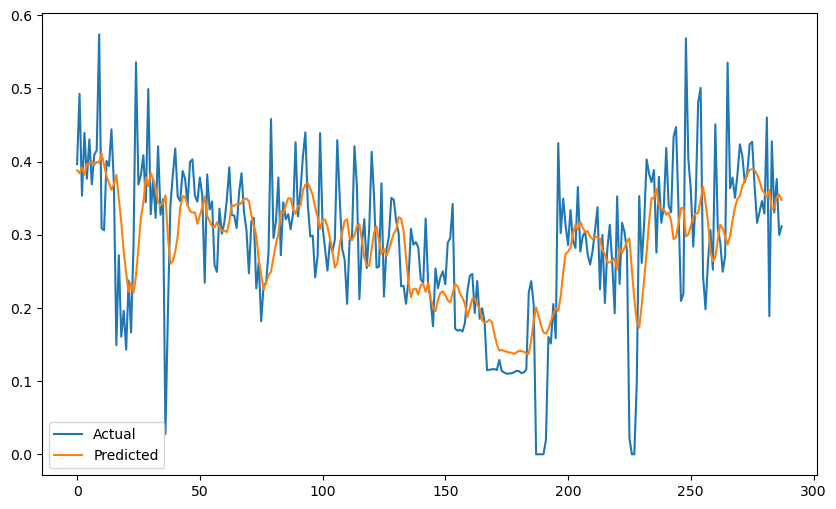

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

## Results and Observations



1.   Model Performance: The LSTM model demonstrated excellent performance, achieving a Mean Absolute Error (MAE) of 0.06 and a Root Mean Squared Error (RMSE) of 0.08, indicating high accuracy in forecasting daily energy consumption.

2. Training Progress: The training and validation losses steadily decreased over 20 epochs, with the lowest validation loss reaching 0.0067, reflecting effective learning and generalization.

3. Visualization: The actual vs. predicted energy consumption plot shows a strong alignment, confirming the model's ability to capture daily consumption patterns accurately.

4. Conclusion: The model successfully forecasts daily energy consumption with high precision, providing reliable predictions suitable for optimizing household energy usage.

